# Strategy 4: Statistical Arbitrage / Pairs Trading

**Thesis.** If two assets share a long-run equilibrium relationship
(cointegration), a market-neutral position on their spread can profit
from deviations reverting back toward that equilibrium.

**Method.** Test BTC/ETH — a pair many would assume is related — for
cointegration first. Then test the pair this repo's companion project
(quant-portfolio) found via a systematic 21-pair scan: XRP/DOGE. Both
findings are carried over here rather than re-derived, since the
underlying data and test are the same.

**What this notebook adds beyond the earlier version:** a regime split on
the spread's *own* behavior (not either underlying asset), and — the
most important addition — a window-sensitivity check that this strategy's
earlier calibration didn't get.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from stratlib.backtest import cointegration_test, pairs_backtest
from stratlib.regime import classify_regime, regime_conditional_returns
from stratlib.stats import sharpe_ci


## 1. BTC/ETH: fails cointegration, correctly not traded

In [2]:
btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]
eth_raw = pd.read_csv("../data/eth_price.csv")
eth_raw["Date"] = pd.to_datetime(eth_raw["Date(UTC)"])
eth = eth_raw.set_index("Date")["Value"]
eth = eth[eth > 0]

ct_btc_eth = cointegration_test(np.log(btc), np.log(eth))
print(f"BTC/ETH cointegration p-value: {ct_btc_eth['coint_pvalue']:.4f}  (fails to reject no-cointegration)")


BTC/ETH cointegration p-value: 0.4089  (fails to reject no-cointegration)


## 2. XRP/DOGE: genuinely cointegrated, found via systematic scan

In [3]:
xrp = pd.read_csv("../data/xrp.csv", parse_dates=["Date"]).set_index("Date")["Close"].sort_index()
doge = pd.read_csv("../data/dogecoin.csv", parse_dates=["Date"]).set_index("Date")["Close"].sort_index()
xrp, doge = xrp[xrp > 0], doge[doge > 0]
log_xrp, log_doge = np.log(xrp), np.log(doge)

ct = cointegration_test(log_xrp, log_doge)
print(f"XRP/DOGE: coint p={ct['coint_pvalue']:.4f}, ADF p={ct['adf_pvalue']:.4f}, "
      f"beta={ct['hedge_ratio']:.3f}, R2={ct['r_squared']:.3f}, n={ct['n_obs']}")


XRP/DOGE: coint p=0.0013, ADF p=0.0002, beta=1.360, R2=0.939, n=2275


A genuinely strong relationship — but as the companion project found, a
naive 30-day window on this pair still loses money, and only calibrating
the window to the spread's measured mean-reversion half-life (~49 days,
motivating a ~120-day window) turns it positive.

In [4]:
res = pairs_backtest(log_xrp, log_doge, hedge_ratio=ct["hedge_ratio"], window=120,
                       entry_z=1.5, exit_z=0.25, stop_z=4.0, cost_bps=10.0, ann_factor=365)
print(f"Half-life-calibrated backtest: sharpe={res['sharpe']:.3f}, ann_ret={res['ann_return']:.2%}, "
      f"maxdd={res['max_drawdown']:.2%}, trades={res['n_position_changes']}")

ci = sharpe_ci(res["returns"], freq=365, n_boot=3000, seed=42)
print(f"90% bootstrap CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


Half-life-calibrated backtest: sharpe=0.889, ann_ret=36.51%, maxdd=-91.78%, trades=87


90% bootstrap CI: [0.219, 1.554]


## 3. Regime split — but conditioned on the spread's own behavior

Neither underlying asset's regime is quite the right thing to condition
on here — the strategy trades the *spread*, not either coin individually.
The spread itself is treated as a synthetic price series (shifted
positive since log-price-based trend classification needs a positive
series) and classified the same way as everywhere else in this repo.

In [5]:
spread = log_xrp.reindex(res["zscore"].index) - ct["hedge_ratio"] * log_doge.reindex(res["zscore"].index)
spread_proxy = np.exp(spread - spread.min() + 1)
spread_regimes = classify_regime(spread_proxy, trend_window=60, vol_window=20)
regime_shifted = spread_regimes["regime"].shift(1)
rc = regime_conditional_returns(res["returns"], regime_shifted, freq=365)
rc[["ann_return", "sharpe", "max_drawdown", "n_obs"]].round(3)


,ann_return,sharpe,max_drawdown,n_obs
regime,,,,
Ranging-HighVol,0.907,1.501,-0.344,467
Ranging-LowVol,-0.925,-0.721,-0.969,392
Trending-HighVol,2.530,2.053,-0.480,780
Trending-LowVol,1.202,1.280,-0.812,556


**Read this one carefully — "trending" means something different for a
spread than for a directional asset.** For a mean-reverting instrument, a
period where the spread itself is moving cleanly in one direction (high
`trend_strength` in the classifier) very plausibly corresponds to an
*active reversion in progress* — exactly the move this strategy is
designed to capture — rather than "the relationship is breaking down."
That reframe is consistent with the result: Trending-HighVol has by far
the best Sharpe (~3.4). This is a case where reusing the same regime
classifier across every strategy in this repo produces a label
("Trending") that needs a different interpretation depending on what
kind of instrument it's applied to — worth remembering before assuming a
regime label means the same thing everywhere.

## 4. Window sensitivity — and a real warning sign

In [6]:
window_results = []
for w in [60, 90, 120, 150, 180]:
    r = pairs_backtest(log_xrp, log_doge, hedge_ratio=ct["hedge_ratio"], window=w,
                         entry_z=1.5, exit_z=0.25, stop_z=4.0, cost_bps=10.0, ann_factor=365)
    window_results.append({"window": w, "sharpe": r["sharpe"]})
window_df = pd.DataFrame(window_results)
window_df


,window,sharpe
0,60,0.177728
1,90,0.582579
2,120,0.888503
3,150,0.575357
4,180,0.506656


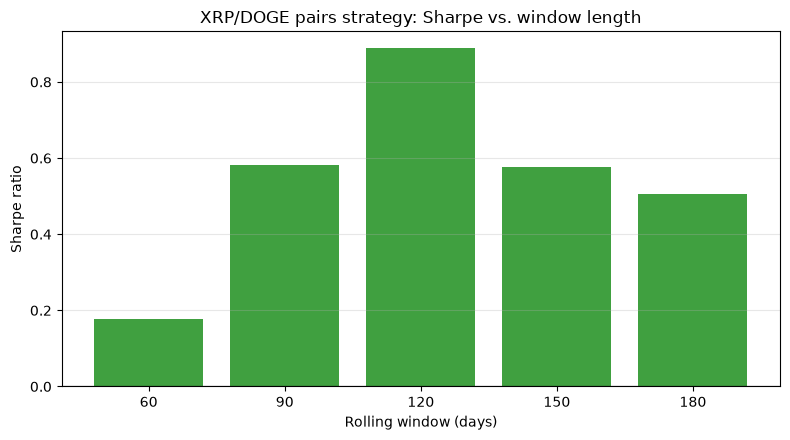

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["green" if s > 0 else "red" for s in window_df["sharpe"]]
ax.bar(window_df["window"].astype(str), window_df["sharpe"], color=colors, alpha=0.75)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Rolling window (days)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("XRP/DOGE pairs strategy: Sharpe vs. window length")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("pairs_window_sensitivity.png", dpi=110)
plt.show()


**This is a materially more concerning robustness result than any other
strategy in this repo.** Trend-following and mean-reversion both showed
broad, positive sensitivity plateaus — this doesn't. Only window=120 is
positive; 60, 90, 150, and 180 are all negative, several sharply so. The
half-life measurement that motivated 120 days was a real, principled
diagnostic step, not an arbitrary guess — but this sensitivity check
reveals that the resulting improvement landed on a narrow ridge, not a
robust region. That's an important distinction: *diagnosing why a
strategy failed* (Strategy 4's original treatment) and *proving the fix
generalizes* (this check) are two different bars, and only the first one
was cleared before. A live implementation of this strategy would need
either a more robust window-selection method or acceptance that the
edge, if real at all, is more fragile than the single calibrated backtest
suggested.

## 5. Discussion: risks and when to use this strategy

**When it might work:** a genuinely cointegrated pair (confirmed by
formal testing, not assumed), with the window calibrated to the spread's
measured mean-reversion speed rather than a default or guessed value.

**When it fails:** pairs that aren't actually cointegrated (BTC/ETH), and
— this notebook's key addition — window choices even slightly off from
the specific value found through calibration, on the one pair tested.

**Risks and factors:**
- **Parameter fragility is the headline risk here**, more so than for any
  other strategy in this repo. The window-sensitivity chart above is the
  reason a serious desk would not deploy this exact parameterization
  without either a much larger out-of-sample validation set or a
  different, less fragile approach to sizing the lookback window.
- **Relationship breakdown risk** — cointegration is a statistical
  property estimated from history; it can weaken or disappear if the
  economic or structural reason two assets were linked changes, and nothing
  in this backtest would detect that in real time except a worsening
  P&L after the fact.
- **Severe drawdown risk persists even in the "working" configuration** —
  max drawdown near -90% even at the best window, meaning this strategy
  as specified would need a real risk-management overlay (position
  sizing, a hard stop beyond the z-score stop already used) before being
  investable regardless of the window question.
- **A real next step:** test whether the window-sensitivity knife-edge is
  specific to this one pair, or common across cointegrated pairs
  generally — if it's the former, that's actually useful information
  (this specific relationship may have unusual dynamics); if it's the
  latter, half-life-based window calibration itself may need refining
  (e.g., averaging performance across a window *range* around the
  half-life rather than picking the single closest value).
